# Customer Churn ML Model

Import files

In [4]:
# ........Install and Import all required libraries.....

import sys
import subprocess

packages = [
    'pandas',
    'numpy',
    'xgboost',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'imbalanced-learn',
    'openpyxl'
]

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '--quiet'])

print('All Packages Installed')


# -------Import Libraries------

# --Core Libraries--
import pandas as pd
import numpy as np

# --Visualization Libraries--
import seaborn as sns
import matplotlib.pyplot as plt

# --ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE


# --- Display Setting
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print("All Libraries Loaded Successfully")

All Packages Installed
All Libraries Loaded Successfully


In [32]:
df = pd.read_excel('Customer Churn Dataset.xlsx')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [33]:
df.shape

(7043, 21)

Dataset Information

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Data Preprocessing

In [35]:
# Check missing Data

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Column "TotalCharges" has 11 missing datapoints.

In [36]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [37]:
df.TotalCharges.dtype

dtype('float64')

In [38]:
df.TotalCharges.unique()

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ],
      shape=(6531,))

<Axes: >

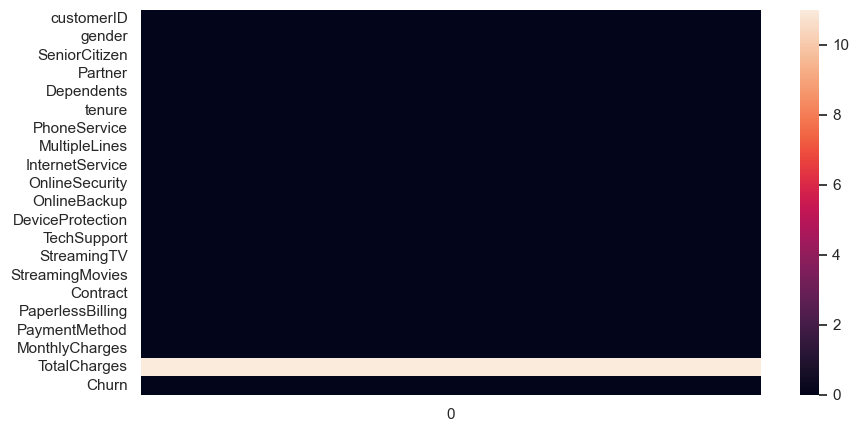

In [16]:
sns.heatmap(df.isnull().sum().to_frame())

In [39]:
# Filling the missing values

df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [40]:
# Checking the categorical variables

cat_cols = df.select_dtypes(include = ['object']).columns.tolist()
for col in cat_cols:
    print(f'{col:20s} > {df[col].unique().tolist()}')
    print()

customerID           > ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU', '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU', '9763-GRSKD', '7469-LKBCI', '8091-TTVAX', '0280-XJGEX', '5129-JLPIS', '3655-SNQYZ', '8191-XWSZG', '9959-WOFKT', '4190-MFLUW', '4183-MYFRB', '8779-QRDMV', '1680-VDCWW', '1066-JKSGK', '3638-WEABW', '6322-HRPFA', '6865-JZNKO', '6467-CHFZW', '8665-UTDHZ', '5248-YGIJN', '8773-HHUOZ', '3841-NFECX', '4929-XIHVW', '6827-IEAUQ', '7310-EGVHZ', '3413-BMNZE', '6234-RAAPL', '6047-YHPVI', '6572-ADKRS', '5380-WJKOV', '8168-UQWWF', '8865-TNMNX', '9489-DEDVP', '9867-JCZSP', '4671-VJLCL', '4080-IIARD', '3714-NTNFO', '5948-UJZLF', '7760-OYPDY', '7639-LIAYI', '2954-PIBKO', '8012-SOUDQ', '9420-LOJKX', '6575-SUVOI', '7495-OOKFY', '4667-QONEA', '1658-BYGOY', '8769-KKTPH', '5067-XJQFU', '3957-SQXML', '5954-BDFSG', '0434-CSFON', '1215-FIGMP', '0526-SXDJP', '0557-ASKVU', '5698-BQJOH', '5122-CYFXA', '8627-ZYGSZ', '3410-YOQBQ', '3170-NMYVV', '7410-OIED

In [41]:
# Drop customer ID
df.drop('customerID', axis=1, inplace=True)

df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [42]:
# Convert 'No phone service' and "No internet service" to "No"
lst = ['No phone service', 'No internet service']

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace(lst, 'No')

# Map the target variable to binary values
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map(binary_map)



In [43]:
# convert the target variable to binary values
df['Churn'] = df['Churn'].map(binary_map)

In [44]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [45]:
# Convert categorical variables to dummy variables
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)


In [46]:
print(f"New Shape of the dataset: {df.shape}")
print(f"\nChurn counts:\n{df["Churn"].value_counts()}")
print(f"\nSample of new columns:\n{df.columns.tolist()}")

New Shape of the dataset: (7043, 24)

Churn counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Sample of new columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [47]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,True,False,False,False,False,True,False
5,0,0,0,0,8,1,1,0,0,1,0,1,1,1,99.65,820.50,1,True,False,False,False,False,True,False
6,1,0,0,1,22,1,1,0,1,0,0,1,0,1,89.10,1949.40,0,True,False,False,False,True,False,False
7,0,0,0,0,10,0,0,1,0,0,0,0,0,0,29.75,301.90,0,False,False,False,False,False,False,True
8,0,0,1,0,28,1,1,0,0,1,1,1,1,1,104.80,3046.05,1,True,False,False,False,False,True,False
9,1,0,0,1,62,1,0,1,1,0,0,0,0,0,56.15,3487.95,0,False,False,True,False,False,False,False


In [48]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,7043.00,0.50,0.50,0.00,0.00,1.00,1.00,1.00
SeniorCitizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Partner,7043.00,0.48,0.50,0.00,0.00,0.00,1.00,1.00
Dependents,7043.00,0.30,0.46,0.00,0.00,0.00,1.00,1.00
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
PhoneService,7043.00,0.90,0.30,0.00,1.00,1.00,1.00,1.00
MultipleLines,7043.00,0.42,0.49,0.00,0.00,0.00,1.00,1.00
OnlineSecurity,7043.00,0.29,0.45,0.00,0.00,0.00,1.00,1.00
OnlineBackup,7043.00,0.34,0.48,0.00,0.00,0.00,1.00,1.00
DeviceProtection,7043.00,0.34,0.48,0.00,0.00,0.00,1.00,1.00


Exploratory Data Analysis

Univariate, Bivariate and Multivariate Analysis

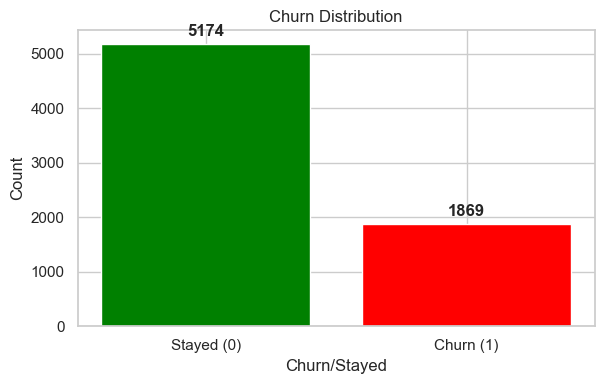

In [53]:
# Churn Distribution
# Determine how many customer churn, and how many customers do not churn. This will help us understand the distribution of the target variable and whether we have a class imbalance problem.

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Stayed (0)', 'Churn (1)'],
         churn_counts.values, 
         color=['green', 'red'])

for i, count in enumerate(churn_counts.values):
    plt.text(i, count + 100, str(count), ha='center', va='bottom', fontweight='bold')
plt.title('Churn Distribution')
plt.xlabel('Churn/Stayed')
plt.tight_layout()
plt.ylabel('Count')
plt.show()

In [58]:
churn_percent = df['Churn'].value_counts()[1] / len(df['Churn']) * 100
print(f"Percentage of customers who churned: {churn_percent:.2f}%")
print(f"Percentage of customers who stayed: {100 - churn_percent:.2f}%")

Percentage of customers who churned: 26.54%
Percentage of customers who stayed: 73.46%


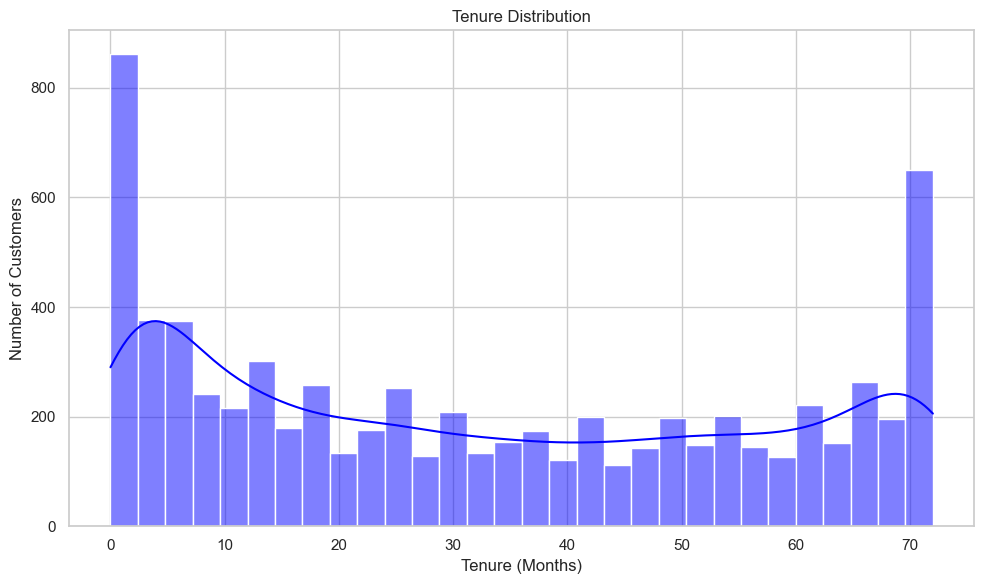

In [59]:
# Tenure distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', bins=30, kde=True, color='blue')
plt.title('Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

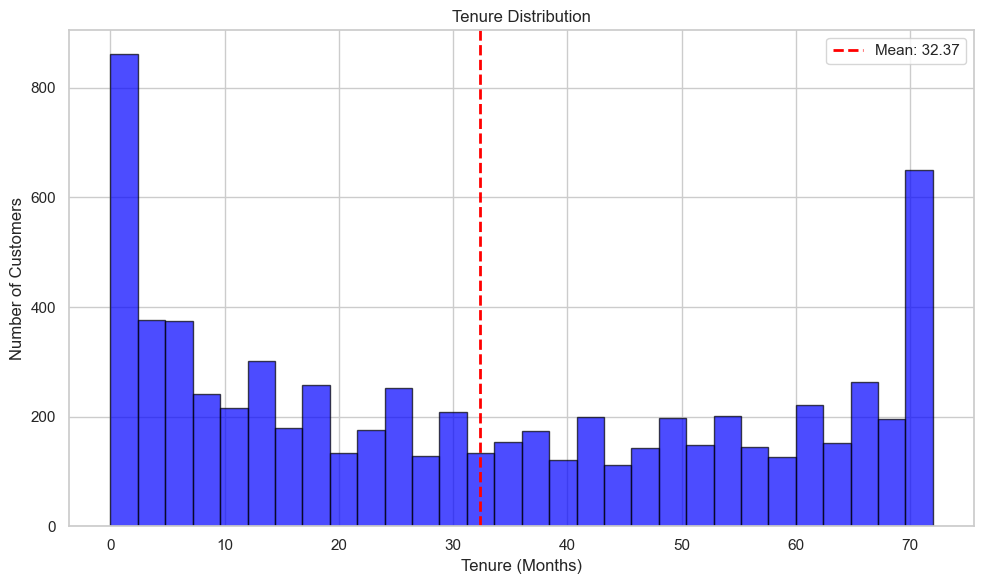

In [60]:
plt.figure(figsize=(10, 6))
plt.hist(df['tenure'], bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(df['tenure'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["tenure"].mean():.2f}')
plt.title('Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

Histogram plot of the tenure column depicts the period of patronage of the customers. 
It can be seen that about 800+ customers leave so quickly (spent 0-3months), less than 200 spent average months (32months)
While about 650 customers stayed upto 70-72 months.

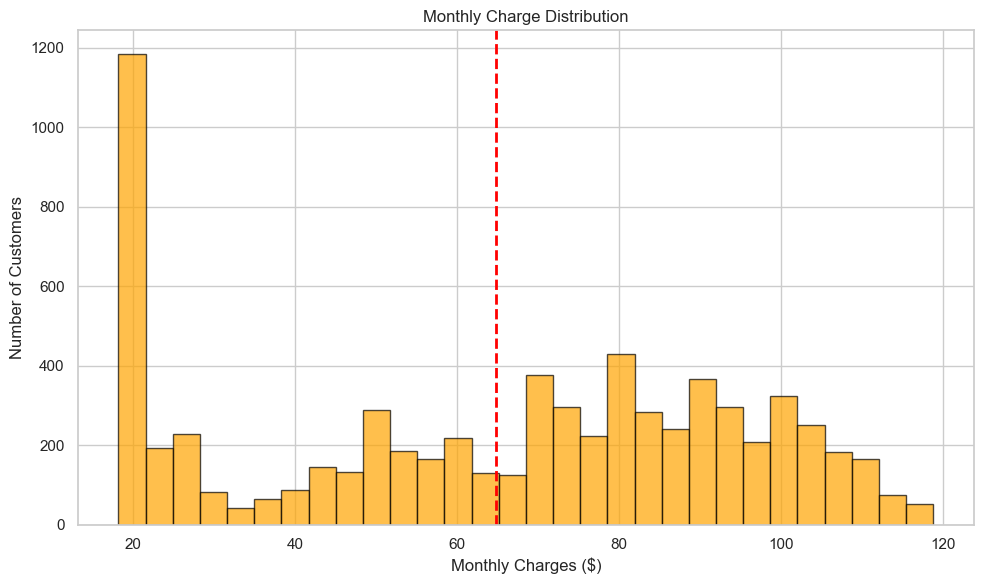

In [61]:
# Monthly charge distribution
plt.figure(figsize=(10, 6))
plt.hist(df['MonthlyCharges'], bins=30, color='orange', edgecolor='black', alpha=0.7)
plt.axvline(df['MonthlyCharges'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["MonthlyCharges"].mean():.2f}')
plt.title('Monthly Charge Distribution')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Customers on cheaper monthly plans are more than those on costly monthly plans.

<Axes: ylabel='MonthlyCharges'>

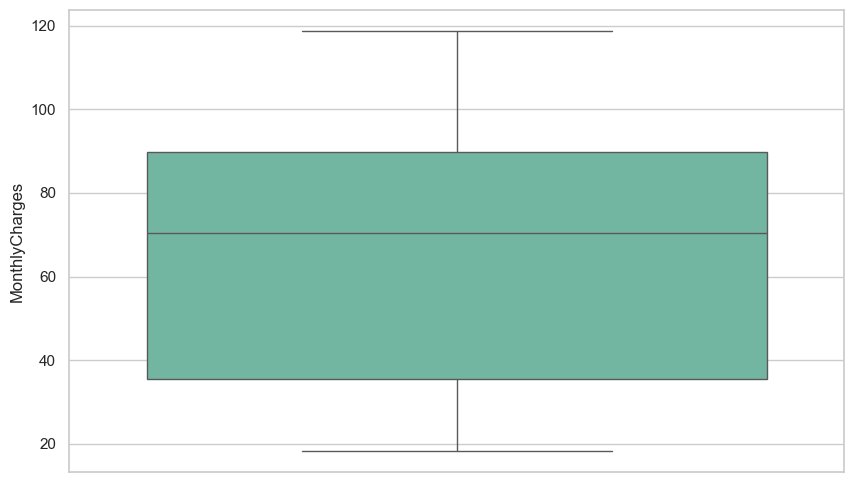

In [62]:
plt.figure(figsize=(10,6))
sns.boxplot(df['MonthlyCharges'])


<Axes: ylabel='tenure'>

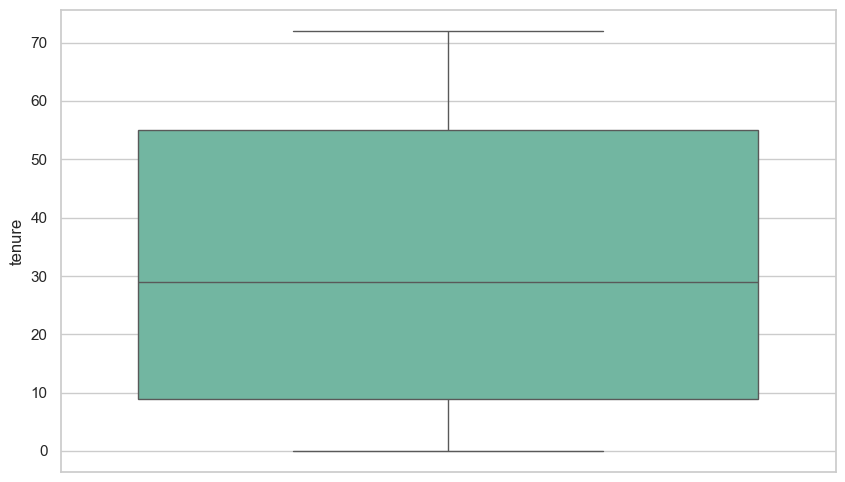

In [64]:
plt.figure(figsize=(10,6))
sns.boxplot(df['tenure'])
